# Import Libraries

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder,LabelEncoder,StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [2]:
df = pd.read_csv("diabetes_dataset.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# Dataset Overview

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# Data Cleaning

In [7]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

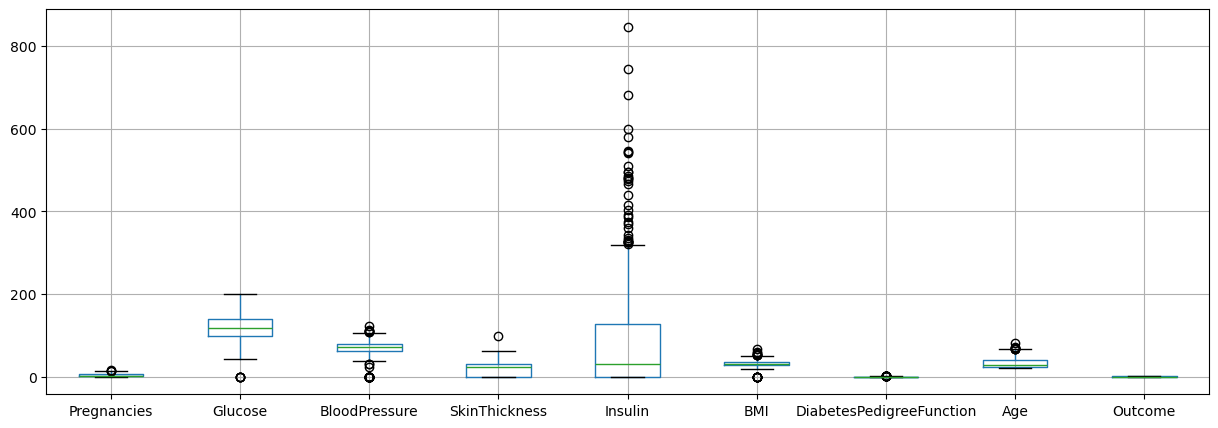

In [9]:
plt.figure(figsize=(15,5)) 
df.boxplot() 
plt.show()

## Correlation

<Axes: >

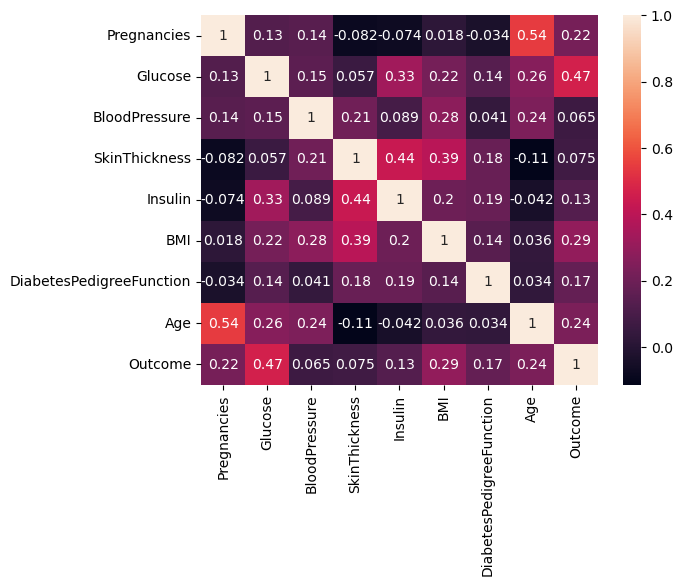

In [10]:
sns.heatmap(df.corr(),annot=True)

# Feature & Target Selection

In [11]:
X = df.iloc[:,:-1]
y = df["Outcome"]

# Train Test Split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.8,random_state=142)
X_train,X_test,y_train,y_test 

(     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
 463            5       88             78             30        0  27.6   
 365            5       99             54             28       83  34.0   
 474            4      114             64              0        0  28.9   
 604            4      183              0              0        0  28.4   
 8              2      197             70             45      543  30.5   
 ..           ...      ...            ...            ...      ...   ...   
 268            0      102             52              0        0  25.1   
 511            0      139             62             17      210  22.1   
 411            1      112             72             30      176  34.4   
 197            3      107             62             13       48  22.9   
 277            0      104             64             23      116  27.8   
 
      DiabetesPedigreeFunction  Age  
 463                     0.258   37  
 365                  

# Feature Scaling

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Training

In [14]:
lr = LogisticRegression()

In [15]:
lr.fit(X_train,y_train)

LogisticRegression()

In [16]:
lr.coef_

array([[ 0.43702585,  1.03342621, -0.25274347,  0.05939774, -0.1419313 ,
         0.63094899,  0.27554852,  0.13165091]])

In [17]:
lr.intercept_

array([-0.82718479])

# Prediction

In [18]:
y_pred = lr.predict(X_test)
y_pred

array([0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0])

# Model Evaluation

In [19]:
confusion_matrix(y_test,y_pred)

array([[95,  6],
       [14, 39]])

<Axes: >

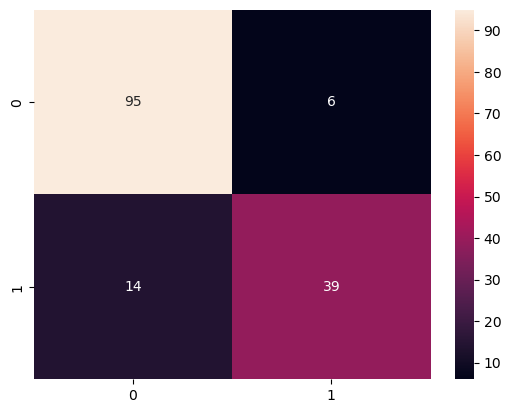

In [20]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='g')

In [21]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90       101
           1       0.87      0.74      0.80        53

    accuracy                           0.87       154
   macro avg       0.87      0.84      0.85       154
weighted avg       0.87      0.87      0.87       154



In [22]:
report = classification_report(y_test,y_pred,output_dict=True)
report

{'0': {'precision': 0.8715596330275229,
  'recall': 0.9405940594059405,
  'f1-score': 0.9047619047619048,
  'support': 101.0},
 '1': {'precision': 0.8666666666666667,
  'recall': 0.7358490566037735,
  'f1-score': 0.7959183673469388,
  'support': 53.0},
 'accuracy': 0.8701298701298701,
 'macro avg': {'precision': 0.8691131498470948,
  'recall': 0.8382215580048571,
  'f1-score': 0.8503401360544218,
  'support': 154.0},
 'weighted avg': {'precision': 0.8698756900591763,
  'recall': 0.8701298701298701,
  'f1-score': 0.8673027652619488,
  'support': 154.0}}

In [23]:
accuracy_score(y_test,y_pred)

0.8701298701298701

In [24]:
print(report['0'])

{'precision': 0.8715596330275229, 'recall': 0.9405940594059405, 'f1-score': 0.9047619047619048, 'support': 101.0}


In [25]:
print(report['1'])

{'precision': 0.8666666666666667, 'recall': 0.7358490566037735, 'f1-score': 0.7959183673469388, 'support': 53.0}


In [26]:
print(f'accuracy of the model :',round(report['accuracy']*100,2))

accuracy of the model : 87.01


# Conclusion

- The Logistic Regression model achieved an accuracy of **87.01%** in predicting diabetes outcomes using medical attributes.  
- This project demonstrates the effectiveness of Logistic Regression for binary classification in healthcare datasets.
- Feature scaling and proper preprocessing helped improve the overall model performance.